In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
df = pd.read_excel('/content/drive/MyDrive/IT24101491.xlsx', index_col="Date")


In [15]:
# Ensure daily returns exist
df['ret_1d'] = df['Adj Close**'].pct_change().fillna(0)


In [16]:
# Compute correlation matrix
corr = df.corr()

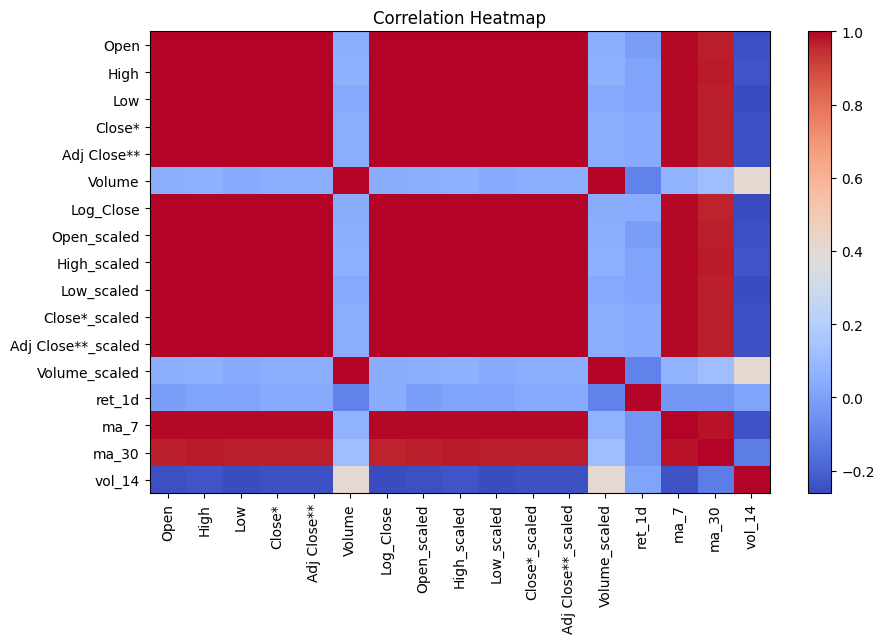

In [17]:
#Plot correlation heatmap
plt.figure(figsize=(10,6))
plt.imshow(corr.values, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# Feature selection based on high correlation
if 'Close*' in corr.index and 'Adj Close**' in corr.columns:
    if pd.notna(corr.loc['Close*', 'Adj Close**']) and corr.loc['Close*', 'Adj Close**'] > 0.98:
        df = df.drop(columns=['Close*'])
        print("Dropped 'Close*' due to high correlation with 'Adj Close**'")



Dropped 'Close*' due to high correlation with 'Adj Close**'


In [19]:
#Reset index so Date becomes a column again
df = df.reset_index()

In [20]:
# Save preprocessed dataset as Excel
df.to_excel("IT24201236.xlsx", index=False)
print("Preprocessed dataset saved as 'IT24201236.xlsx'")

Preprocessed dataset saved as 'IT24201236.xlsx'
